# 03. Model Karşılaştırması

Bu notebookta, Logistic Regression, Random Forest, k-Nearest Neighbors (kNN) ve Naive Bayes modelleri kurularak Kredi Kartı Sahtekarlık verisi üzerinde eğitilmiş ve performansları Accuracy, Precision, Recall, F1 ve F2 skorları üzerinden karşılaştırılmıştır.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, fbeta_score, confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

## 1. Verilerin Yüklenmesi

In [2]:
# Preprocessing adımında kaydettiğimiz verileri yüklüyoruz.
X_train = pd.read_csv('../outputs/tables/X_train.csv')
X_test = pd.read_csv('../outputs/tables/X_test.csv')
y_train = pd.read_csv('../outputs/tables/y_train.csv').values.ravel()
y_test = pd.read_csv('../outputs/tables/y_test.csv').values.ravel()

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)

Eğitim seti boyutu: (227845, 30)
Test seti boyutu: (56962, 30)


## 2. Modellerin Eğitilmesi ve Değerlendirilmesi
Her modeli değerlendirebilmek ve raporlamak için yardımcı bir fonksiyon yazıyoruz.

In [3]:
results = {}

def evaluate_model(model_name, y_true, y_pred, cm_filename):
    # Metriklerin hesaplanması
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    f2 = fbeta_score(y_true, y_pred, beta=2)
    
    results[model_name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-score': f1, 'F2-score': f2}
    
    print(f"--- {model_name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"F2-score : {f2:.4f}\n")
    
    # Karmaşıklık Matrisi Çizimi
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Tahmin (Predicted)')
    plt.ylabel('Gerçek (Actual)')
    plt.tight_layout()
    plt.savefig(f'../outputs/figures/{cm_filename}')
    plt.show()

### 2.1 Logistic Regression

--- Logistic Regression ---
Accuracy : 0.9991
Precision: 0.8182
Recall   : 0.6429
F1-score : 0.7200
F2-score : 0.6716



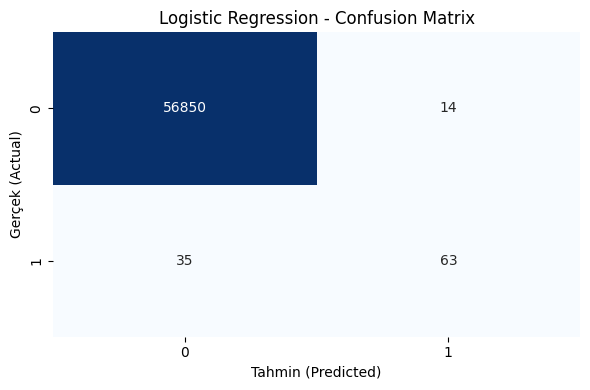

In [4]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
evaluate_model('Logistic Regression', y_test, y_pred_lr, 'confusion_matrix_lr.png')

### 2.2 Random Forest
Not: Random Forest eğitimi büyük veri setlerinde biraz zaman alabilir.

--- Random Forest ---
Accuracy : 0.9996
Precision: 0.9405
Recall   : 0.8061
F1-score : 0.8681
F2-score : 0.8298



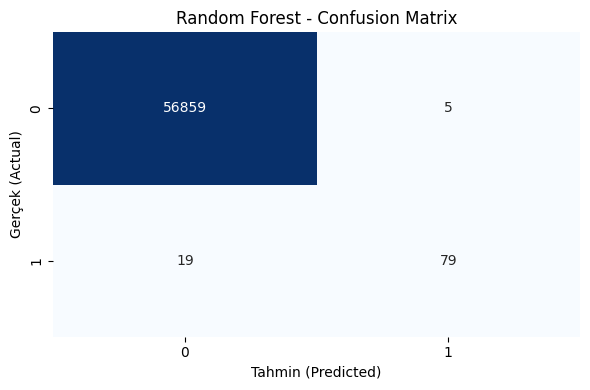

In [5]:
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
evaluate_model('Random Forest', y_test, y_pred_rf, 'confusion_matrix_rf.png')

### 2.3 k-Nearest Neighbors (kNN)

--- kNN ---
Accuracy : 0.9995
Precision: 0.9167
Recall   : 0.7857
F1-score : 0.8462
F2-score : 0.8088



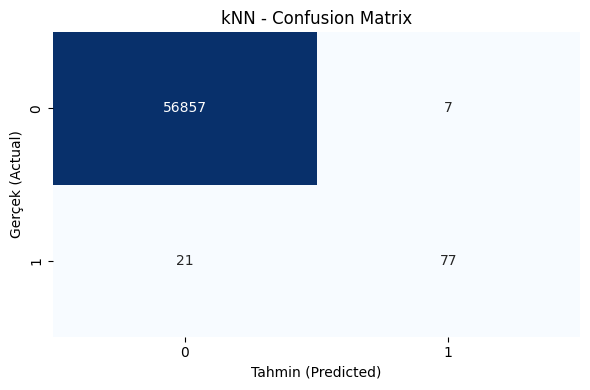

In [6]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
evaluate_model('kNN', y_test, y_pred_knn, 'confusion_matrix_knn.png')

### 2.4 Naive Bayes (Gaussian)

--- Naive Bayes ---
Accuracy : 0.9764
Precision: 0.0588
Recall   : 0.8469
F1-score : 0.1099
F2-score : 0.2300



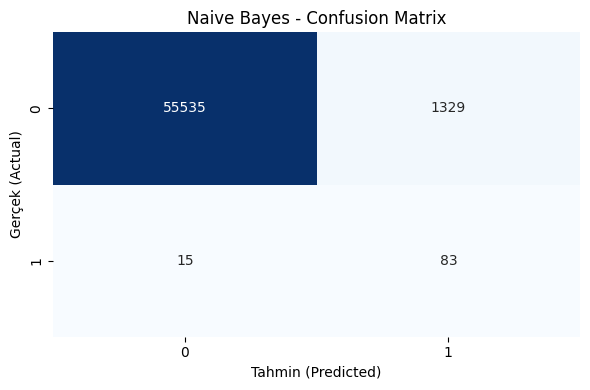

In [7]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
evaluate_model('Naive Bayes', y_test, y_pred_nb, 'confusion_matrix_nb.png')

## 3. Genel Karşılaştırma

In [8]:
results_df = pd.DataFrame(results).T
display(results_df)

# Tabloyu CSV olarak kaydetme
results_df.to_csv('../outputs/tables/model_comparison.csv')
print("Karşılaştırma modeli ../outputs/tables/ altına kaydedildi.")

,Accuracy,Precision,Recall,F1-score,F2-score
Logistic Regression,0.999140,0.818182,0.642857,0.720000,0.671642
Random Forest,0.999579,0.940476,0.806122,0.868132,0.829832
kNN,0.999508,0.916667,0.785714,0.846154,0.808824
Naive Bayes,0.976405,0.058782,0.846939,0.109934,0.230044


Karşılaştırma modeli ../outputs/tables/ altına kaydedildi.
